【모델 예측 성능평가】
- 모델 예측 성능평가하는 학습모델이 실제값을 얼마나 정확하게 맞추었는지를  나타내는 것이다.
- 머신러닝 모델은 여러가지 방법으로 예측 성능을 평가할 수 있다.
- 이를 성능평가지표(Evaluation Metric)라 하며, 일반적으로 분석 알고리즘이 회귀분석인지 분류분석인지에 따라 여러 종류가 있다.
-  회귀분석 성능평가 종류

|종류	|	잔차 계산 |	이상치 영향|
|---|---|---|
|MAE	(Mean Absolute Error) |	Absolute Value|	Yes|
|MSE	(Mean Squared Error)	|Square|	No|
|RMSE	(Root Mean Squared Error) |	Square|	No|
|MAPE	(Mean Absolute Percentage Error)	| Absolute Value|	 Yes|
|MPE	(Mean Percentage Error)	|N/A	|Yes|


### 1. 평균 절대 오차 (MAE : Mean Absolute Error)
- 실제 값과 예측 값의 차이(Error)를 절대값으로 변환해 평균한다.
- MAE는 에러에 절대값을 취하기 때문에 에러의 크기 그대로 반영된다.
- 에러에 따른 손실이 선형적으로 올라갈 때 적합하다.
- 0에 가까울수록 좋은 모델이라고 할 수 있다.
- 이상치에 영향을 받는다.
- 회귀평가를 위한 지표로 주로 쓰인다


$$ MAE = \frac{1}{n}\sum_{i=1}^{n} |Y_i-\hat{Y_i}|$$


python으로 MAE 구현

In [2]:
import numpy as np

testVal = np.array([1,   1.7,  1.5])  # 실제값
predVal = np.array([1.1,   2,   1.7]) # 예측값
print(testVal-predVal)

# 수식
mae_custom = sum(np.abs(testVal - predVal)) / len(predVal)
print(mae_custom)

[-0.1 -0.3 -0.2]
0.20000000000000004


sklearn의 mean_absolute_error( )로 계산

In [3]:
from sklearn.metrics import mean_absolute_error
testVal = np.array([1,   1.7,  1.5])
predVal = np.array([1.1,   2,   1.7])

mean_absolute_error(testVal, predVal)       # 함수 이용해서 가능하다.

0.20000000000000004

### 2 평균 제곱 오차(MSE : Mean Squared Error)

- 실제값과 예측값의 차이를 제곱해 평균한다.
- 예측값과 실제값 차이의 면적의 평균과 같다.
- 이상값(특이값)이 존재하면 수치가 많이 늘어난다.
- MSE가 0에 가까울수록 추측한 값이 원본에 가까운 것이기 때문에 정확도가 높다고 할 수 있다.


 $$ MSE = \frac{1}{n}\sum_{i=1}^{n} (Y_i-\hat{Y_i})^2$$


python으로 mse으로 구현

In [4]:
import numpy as np

testVal = np.array([1,   1.7,  1.5])
predVal = np.array([1.1,   2,   1.7])

mse_custom  = sum((testVal - predVal)**2) / len(predVal)
print(mse_custom)

0.04666666666666667


 sklearn의 mean_squared_error( )로 계산

In [5]:
import sklearn.metrics 
print(dir(sklearn.metrics))


['ConfusionMatrixDisplay', 'DetCurveDisplay', 'DistanceMetric', 'PrecisionRecallDisplay', 'PredictionErrorDisplay', 'RocCurveDisplay', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_base', '_classification', '_dist_metrics', '_pairwise_distances_reduction', '_pairwise_fast', '_plot', '_ranking', '_regression', '_scorer', 'accuracy_score', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'auc', 'average_precision_score', 'balanced_accuracy_score', 'brier_score_loss', 'calinski_harabasz_score', 'check_scoring', 'class_likelihood_ratios', 'classification_report', 'cluster', 'cohen_kappa_score', 'completeness_score', 'confusion_matrix', 'confusion_matrix_at_thresholds', 'consensus_score', 'coverage_error', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'd2_pinball_score', 'd2_tweedie_score', 'davies_bouldin_score', 'dcg_score', 'det_curve', 'euclidean_distances', 'explained_variance_s

In [6]:
from sklearn.metrics import mean_squared_error
testVal = np.array([1,   1.7,  1.5])
predVal = np.array([1.1,   2,   1.7])

mean_squared_error(testVal, predVal)

0.04666666666666667

### 3 루트 평균 제곱근 오차(RMSE)

- 실제값과 예측값의 차이를 제곱해 평균한 것에 루트를 씌운다
- 에러에 제곱을 하면 에러가 클수록 그에 따른 가중치가 높이 반영된다.
- 이때, 손실이 기하급수적으로 증가하는 상황에서 실제 오류평균보다 값이 더 커지지 않도록 하기 위해 사용한다.


 $$ RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (Y_i-\hat{Y_i})^2}$$

python으로 rmse 구현

In [7]:
import numpy as np

testVal = np.array([1,   1.7,  1.5])
predVal = np.array([1.1,   2,   1.7])

rmse_custom = np.sqrt(sum((testVal - predVal)**2) / len(predVal))       #np.sqrt() 제곱근 함수 이용
print(rmse_custom)

0.21602468994692867


sklearn의 mean_squared_error( )로 계산

In [8]:
print(sklearn.__version__)

1.9.0


In [9]:
from sklearn.metrics import  root_mean_squared_error
testVal = np.array([1,   1.7,  1.5])
predVal = np.array([1.1,   2,   1.7])

root_mean_squared_error(testVal, predVal)

0.21602468994692867

### 4 평균 제곱 로그 오차 (MSLE : Mean Squared Log Error)

- 실제값과 예측값의 차이를 제곱해 평균한 것에 로그를 적용한다.
- RMSE와 같이 손실이 기하급수적으로 증가하는 상황에서 실제 오류평균보다 값이 더 커지지 않도록 해준다.
 $$ MSLE = \log(\frac{1}{n}\sum_{i=1}^{n} (Y_i-\hat{Y_i})^2)$$

python으로 msle 구현

In [10]:
import numpy as np

testVal = np.array([1, 2, 3, 2, 3, 5, 4, 6, 5, 6, 7])
predVal = np.array([1, 1, 2, 2, 3, 4, 4, 5, 5, 7, 7])

# np.log1p(x)는 np.log(x + 1)과 같다.
# 값이 0일 때 log(0) = -∞ 가 되는 것을 방지하기 위해 모든 값에 1을 더해주는 과정이다.
msle_custom = np.mean((np.log1p(testVal) - np.log1p(predVal)) **2)
print(msle_custom)

0.029272467607503516


In [11]:
from sklearn.metrics import mean_squared_log_error

testVal =  np.array([1, 2, 3, 2, 3, 5, 4, 6, 5, 6, 7])
predVal = np.array([1, 1, 2, 2, 3, 4, 4, 5, 5, 7, 7])

mean_squared_log_error(testVal, predVal)


0.029272467607503516

In [12]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns

In [16]:
#############################
###########난수발생###########

# 0 이상 1 미만의 균등분포에서 무작위로 추출한 실수 10갸룰 1차원 배열(array)로 반환
date = np.random.rand(10)
print(date)

#가우시안 정규분포를 의미한다.수학자 카를 프리드리히 가우스(carl Friedrich Gauss)의 이름을 따서 명명되었다. 정규분포는 평균과 표준편차를 이용하여 정의된다. 평균은 데이터의 중심 위치를 나타내고, 표준편차는 데이터의 분산 정도를 나타낸다.
# 평균이 0이고 표준편차가 1인 정규분포에서 무작위로 추출한 실수 10개를 1차원 배열(array)로 반환
date = np.random.randn(10)  
print(date)

#균일 분포의 정수 난수
data = np.random.randint(10)  # 1~9 사이의 정수 난수 10개 생성
print(data)

[0.43042278 0.4484233  0.46645238 0.40089744 0.2971752  0.7732506
 0.82452939 0.79124068 0.78438005 0.55500451]
[-0.86233225  0.27105996 -1.04466251 -0.38121288  0.34749778  0.00534686
 -0.56768896 -0.54983288  1.50291652  0.10548755]
4


In [25]:
print('np.random.shuffle')
#np.random.shuffle()는 배열의 순서를 무작위로 섞는 함수이다. 원본 배열을 직접 변경하며, 반환값은 없다.
data = np.arange(10)  # 0~9까지의 정수 배열 생성
print('원본 배열:', data)

#배열의 요소를 섞어서 다시 배열에 저장
item = np.random.shuffle(data)
print(item)  # None 출력, 반환값 없음
print('섞인 배열:', data)


########데이터 순서바꾸기########
print('np.random.prermutation()는 배열의 순서를 무작위로 섞는 함수이다. 원본 배열을 직접 변경하지 않으며, 반환값은 섞인 배열이다.')
#np.random.shuffle()는 배열의 순서를 무작위로 섞는 함수이다. 원본 배열을 직접 변경하며, 반환값은 없다.
data = np.arange(10)  # 0~9까지의 정수 배열 생성
print( data)

#배열의 요소를 섞어서 다시 배열에 저장
item = np.random.permutation(data)
print(item)  # None 출력, 반환값 없음
print('섞인 배열:', data)

np.random.shuffle
원본 배열: [0 1 2 3 4 5 6 7 8 9]
None
섞인 배열: [7 1 5 3 6 9 2 4 8 0]
np.random.prermutation()는 배열의 순서를 무작위로 섞는 함수이다. 원본 배열을 직접 변경하지 않으며, 반환값은 섞인 배열이다.
[0 1 2 3 4 5 6 7 8 9]
[1 3 7 5 9 6 0 4 2 8]
섞인 배열: [0 1 2 3 4 5 6 7 8 9]


In [26]:
#########데이터 순서 바꾸기#########
print('np.random.shuffle')
# np.random.shuffle : 배열의 요소 변경
data = np.arange(10)        # start, stop, step arrange(stop), arrange(start, stop), arrange(start, stop, step)
print(data)

# 배열의 요소를 섞어서 다시 배열에 저장
item = np.random.shuffle(data)
print(item)     # shuffle은 리턴값이 없으므로 None을 리턴한다.
print(data)


print('np.random.permutation')
data = np.arange(10)
print(data)
# np.random.permutation()은 배열의 요소를 그대로 유지한다.
# 즉, data의 배열은 변경되지 않는다.
item = np.random.permutation(data)
print(item)
print(data)

np.random.shuffle
[0 1 2 3 4 5 6 7 8 9]
None
[5 1 6 8 9 3 7 0 2 4]
np.random.permutation
[0 1 2 3 4 5 6 7 8 9]
[3 5 9 1 6 7 0 8 4 2]
[0 1 2 3 4 5 6 7 8 9]


In [29]:
########################
######데이터샘플링######## 
#np.random.choice()는 주어진 1차원 배열에서 임의의 샘플을 추출하는 함수이다. 이때, 샘플링은 복원추출과 비복원추출로 나눌 수 있다. 복원추출은 이미 선택된 샘플을 다시 선택할 수 있는 경우를 의미하며, 비복원추출은 이미 선택된 샘플을 다시 선택할 수 없는 경우를 의미한다.
#a : 배열이면 배열자체,정수이면 arange(a)명령으로 배열을 생성한다.
#size : 샘플링할 숫자,정수
#replace : boolean. True이면 복원추출, False이면 비복원추출
#p : 1차원 배열. 각 원소가 선택될 확률을 나타내는 배열. 지정하지 않으면 균등분포로 샘플링한다.

# 0~4 사이의 정수 중에서 5개를 비복원추출하여 샘플링
print(np.random.choice(5, 5, replace=False))

data = np.arange(10)  # 0~9까지의 정수 배열 생성
print(np.random.choice(data, 5))

[0 1 4 3 2]
[1 7 8 0 2]


#### 추세선(Trend Line)
- 추세선(Trend Line)은 데이터의 추세를 그래픽으로 표시하고 예측 문제를 분석하는데 사용된다.
- 이러한 분석을 회귀분석(예측을 위해 사용하는 통계분석의 한가지)이라고 하며,
회귀분석을 사용하여 실제 데이터가 존재하지 않는 범위의 값을 예측할 수 있다.
- 추세선을 사용할 수 있는 차트 : 누적형이 아닌 2차원 영역형, 가로 막대형, 세로 막대형, 꺾은선형, 주식형,분산형, 거품형
- 추세선을 사용할 수 없는 차트 : 3차원, 누적형, 방사형, 원형, 표면형, 도넛형

In [32]:
x = 2 * np.random.rand(100, 1)  # 0~2 사이의 균등분포에서 무작위로 추출한 실수 100개를 2차원 배열로 반환
print(x.shape)  # (100, 1) 출력, 100행 1열의 배열
# print(x[:5])  # 배열의 처음 5개 요소 출력
# print(x)

(100, 1)


(100, 1)
(100, 1)
(100, 2)
          x          y
0  1.579618  13.455701
1  0.260787   7.321238
2  0.369886   8.315916
3  1.297415  12.202928
4  0.432923   6.861960


<Axes: xlabel='x', ylabel='y'>

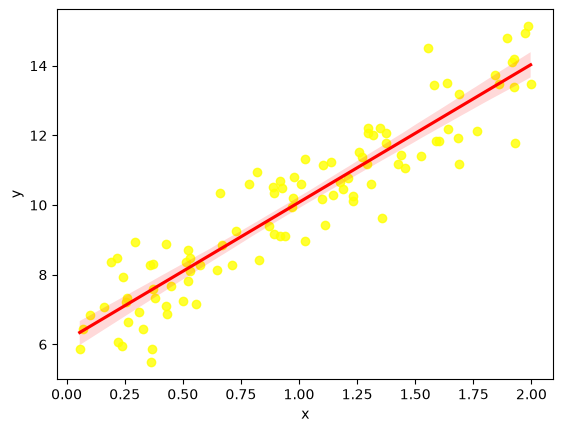

In [ ]:
# y = 4x + 6
x = 2 * np.random.rand(100, 1)  # 0~2 사이의 균등분포에서 무작위로 추출한 실수 100개를 2차원 배열로 반환
print(x.shape)  # (100, 1) 출력, 100행 1열의 배열
# print(x)
y = 6 + 4 * x + np.random.randn(100, 1)  # 정규분포를 따르는 난수를 더해준다.
print(y.shape)  # (100, 1) 출력, 100행 1열의 배열
# print(y)

# plt.scatter(x, y)  # 산점도 그래프 그리기

pd_x = pd.DataFrame(x, columns=['x'])  # x를 DataFrame으로 변환
pd_y = pd.DataFrame(y, columns=['y'])  # y를 DataFrame으로 변환
pd_df = pd.concat([pd_x, pd_y], axis=1)  # x와 y를 합쳐서 DataFrame 생성
print(pd_df.shape)  # DataFrame의 행과 열의 개수 출력
print(pd_df.head())  # DataFrame의 처음 5개 행 출력

sns.regplot(x='x', y='y', data=pd_df, line_kws={'color': 'red'}, scatter_kws={'color': 'yellow'})  # 회귀선이 포함된 산점도 그래프 그리기




### 경사 하강법(gradient_descent_steps) _MSE(평균제곱오차계산식)
- 경사하강법(Gradient Descent)은 함수의 손실(오차)을 최소화하기 위해 기울기(Gradient)가 낮은 방향으로 매개변수를 반복해서 업데이트하는 최적화 알고리즘
- 파라미터 (Parameter) :  스스로 학습하며 최적의 값을 찾아가는 변수 -w, b

- 하이퍼파라미터 (Hyperparameter) : 모델이 학습을 시작하기 전에, 사람(개발자)이 외부에서 직접 설정해 주는 값 - learning_rate, l1, l2

추정된 w: 3.770 (실제 정답: 4)
추정된 b: 6.215 (실제 정답: 6)
Gradient Descent Total Cost: 0.8066


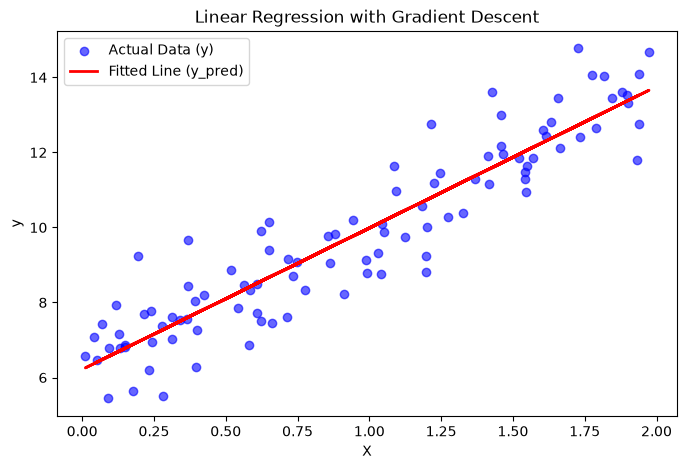

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_weight_updates(w, b, X, y, learning_rate=0.01, l1=0.2, l2=0.7):
    N = len(y)  # 데이터 개수     
    
    # 1. 예측값 및 오차 계산
    y_pred = np.dot(X, w.T) + b   # 예측값: (N, 1)
    diff = y - y_pred             # 실제값 - 예측값: (N, 1)

    # 2. b_update를 dot행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성
    b_factors = np.ones((N, 1))

    # 3. 기울기 방향 업데이트량 구하기 
    # (diff = y - y_pred 이므로 가중치를 오차 방향으로 '더해'주기 위한 + 값)
    w_update = (1 / N) * learning_rate * np.dot(X.T, diff)
    b_update = (1 / N) * learning_rate * np.dot(b_factors.T, diff)
    
    return w_update, b_update

# 입력 인자 epochs로 주어진 횟수만큼 반복적으로 w와 b를 업데이트함
def gradient_descent_steps(X, y, epochs=1000, learning_rate=0.1):
    # w와 b를 모두 0으로 초기화
    w = np.zeros((1, 1))
    b = np.zeros((1, 1))   # y = wX + b

    for ind in range(epochs):
        w_update, b_update = get_weight_updates(w, b, X, y, learning_rate=learning_rate)
        
        # [수정] 빼기(-)가 아닌 더하기(+)를 수행해야 오차가 줄어듭니다.
        w = w + w_update
        b = b + b_update
        
    return w, b

# MSE(평균제곱오차) 계산 함수
def get_cost(y, y_pred):
    N = len(y)
    cost = np.sum(np.square(y - y_pred)) / N
    return cost

# --------------------------------------------------
# 데이터 생성 및 실행
# --------------------------------------------------
np.random.seed(42)  # 재현성을 위한 난수 고정
X = 2 * np.random.rand(100, 1)
y = 6 + 4 * X + np.random.randn(100, 1)   # 실제 타깃: w=4, b=6

# 에포크를 1000으로 설정하여 충분히 수렴시킴
w, b = gradient_descent_steps(X, y, epochs=1000, learning_rate=0.05)

print(f'추정된 w: {w[0, 0]:.3f} (실제 정답: 4)')
print(f'추정된 b: {b[0, 0]:.3f} (실제 정답: 6)')

y_pred = w[0, 0] * X + b
print(f'Gradient Descent Total Cost: {get_cost(y, y_pred):.4f}')

# 시각화
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Actual Data (y)', color='blue', alpha=0.6)
plt.plot(X, y_pred, label='Fitted Line (y_pred)', color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression with Gradient Descent')
plt.legend()
plt.show()

In [ ]:
print('np.random.permutation')
data = np.arange(10)
print(data)
# np.random.permutation()은 배열의 요소를 그대로 유지한다.
#즉, data의 배열은 변경되지 않는다
item = np.random.permutation(data)
print(item)
print(data)